In [12]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import numpy as np
import pandas as pd
import librosa
import pickle
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt

In [2]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
sample_rate = 22050
times = 4
audio_files_meta = "metadata.csv"

In [3]:
df = pd.read_csv(audio_files_meta)
augmented_df = pd.read_csv(augmented_meta)

In [ ]:
def extract_features(file_path):
    nmfcc = 13
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)
    mfcc   = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=nmfcc)
    chroma = librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sample_rate)
    rms    = librosa.feature.rms(y=y)

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    return np.hstack([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        chroma.mean(axis=1), chroma.std(axis=1),
        rms.mean(), rms.std(),
        spectral_centroid.mean(), spectral_centroid.std(),
        zero_crossing.mean(), zero_crossing.std()
    ])

In [13]:
X, y_emotion_raw, y_intensity_raw, y_gender_raw = [], [], [], []

for _, row in augmented_df.iterrows():
    folder = out_dir if row["augmentation"] != "original" else in_dir
    if "wav" in row["file_name"]:
      path   = os.path.join(folder, row["file_name"])
    else:
      path   = os.path.join(folder, row["file_name"]+".wav")

    X.append(extract_features(path))
    y_emotion_raw.append(row["emotion"])
    y_intensity_raw.append(row["intensity"])
    y_gender_raw.append(row["gender"])

X = np.array(X)
y_emotion_raw = np.array(y_emotion_raw)
y_intensity_raw = np.array(y_intensity_raw)
y_gender_raw = np.array(y_gender_raw)

print(f"Feature matrix: {X.shape}")
print(f"Emotion labels: {np.unique(y_emotion_raw)}")
print(f"Intensity labels: {np.unique(y_intensity_raw)}")
print(f"Gender labels: {np.unique(y_gender_raw)}")

emotion_encoder = LabelEncoder()
intensity_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
y_intensity = intensity_encoder.fit_transform(y_intensity_raw)
y_gender = gender_encoder.fit_transform(y_gender_raw)

y = np.column_stack([y_emotion, y_intensity, y_gender])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_emotion
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(emotion_encoder, os.path.join("models","svm_emotion_encoder.pkl"))
joblib.dump(intensity_encoder, os.path.join("models","svm_intensity_encoder.pkl"))
joblib.dump(gender_encoder, os.path.join("models","svm_gender_encoder.pkl"))
joblib.dump(scaler, os.path.join("models","svm_scaler.gz"))

Feature matrix: (3360, 52)
Emotion labels: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'sad' 'surprised']
Intensity labels: ['normal' 'strong']
Gender labels: ['female' 'male']


['models/svm_scaler.gz']

Fitting 5 folds for each of 9 candidates, totalling 45 fits



Best params: {'estimator__C': 10, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}

EMOTION CLASSIFICATION
              precision    recall  f1-score   support

       angry       0.69      0.70      0.69        96
        calm       0.66      0.75      0.70        96
     disgust       0.58      0.66      0.61        96
     fearful       0.60      0.46      0.52        96
       happy       0.64      0.70      0.67        96
         sad       0.50      0.44      0.47        96
   surprised       0.64      0.64      0.64        96

    accuracy                           0.62       672
   macro avg       0.62      0.62      0.61       672
weighted avg       0.62      0.62      0.61       672


INTENSITY CLASSIFICATION
              precision    recall  f1-score   support

      normal       0.78      0.78      0.78       356
      strong       0.75      0.76      0.76       316

    accuracy                           0.77       672
   macro avg       0.77      0.77      0.77

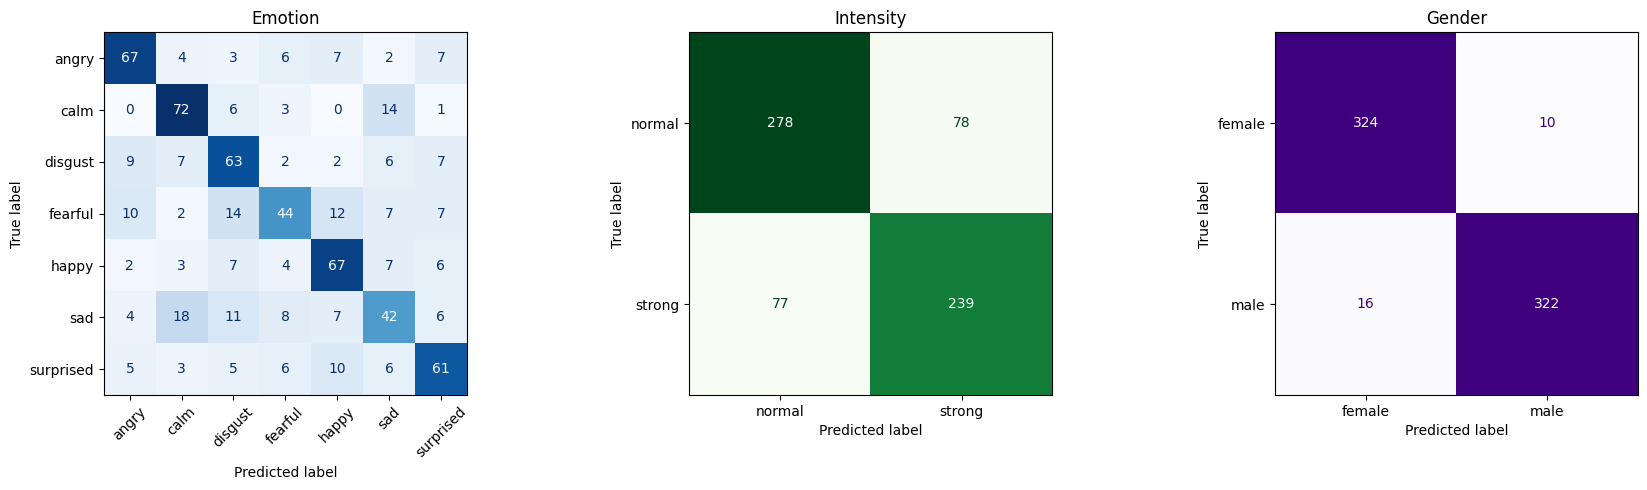

In [ ]:
param_grid = {
    "estimator__C":     [0.1, 1, 10],
    "estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__kernel": ['rbf'], 
}

base_svm = MultiOutputClassifier(
    SVC(class_weight="balanced", probability=True)
)

from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
multi_svm = GridSearchCV(
    base_svm,
    param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

multi_svm.fit(X_train, y_train)

joblib.dump(multi_svm, os.path.join("models","svm_multi.pkl"))

print(f"\nBest params: {multi_svm.best_params_}")

y_pred = multi_svm.predict(X_test)

y_emotion_pred = y_pred[:, 0]
y_intensity_pred = y_pred[:, 1]
y_gender_pred = y_pred[:, 2]

y_emotion_test = y_test[:, 0]
y_intensity_test = y_test[:, 1]
y_gender_test = y_test[:, 2]

print("\n" + "=" * 60)
print("EMOTION CLASSIFICATION")
print("=" * 60)
print(classification_report(y_emotion_test, y_emotion_pred, target_names=emotion_encoder.classes_))

print("\n" + "=" * 60)
print("INTENSITY CLASSIFICATION")
print("=" * 60)
print(classification_report(y_intensity_test, y_intensity_pred, target_names=intensity_encoder.classes_))

print("\n" + "=" * 60)
print("GENDER CLASSIFICATION")
print("=" * 60)
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_encoder.classes_))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_emotion = confusion_matrix(y_emotion_test, y_emotion_pred)
ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion")

cm_intensity = confusion_matrix(y_intensity_test, y_intensity_pred)
ConfusionMatrixDisplay(cm_intensity, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity")

cm_gender = confusion_matrix(y_gender_test, y_gender_pred)
ConfusionMatrixDisplay(cm_gender, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender")

plt.tight_layout()
plt.show()

In [ ]:
scaler = joblib.load(os.path.join("models","svm_scaler.gz"))
emotion_encoder = joblib.load(os.path.join("models","svm_emotion_encoder.pkl"))
intensity_encoder = joblib.load(os.path.join("models","svm_intensity_encoder.pkl"))
gender_encoder = joblib.load(os.path.join("models","svm_gender_encoder.pkl"))

multi_svm = joblib.load(os.path.join("models","svm_multi.pkl"))

In [21]:
feature = extract_features("12_Angry_Men.wav")
feature_scaled = scaler.transform([feature])

predictions = multi_svm.predict(feature_scaled)[0]

print(f"Raw predictions: {predictions}")
print(f"Emotion classes: {emotion_encoder.classes_}")
print(f"Intensity classes: {intensity_encoder.classes_}")
print(f"Gender classes: {gender_encoder.classes_}")

predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

print(f"\nPredicted Emotion: {predicted_emotion}")
print(f"Predicted Intensity: {predicted_intensity}")
print(f"Predicted Gender: {predicted_gender}")

Raw predictions: [0 1 0]
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'sad' 'surprised']
Intensity classes: ['normal' 'strong']
Gender classes: ['female' 'male']

Predicted Emotion: angry
Predicted Intensity: strong
Predicted Gender: female
